##### This is for the heatmap between the different vairations (and from their basline units)

In [1]:
#importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data

df = pd.read_csv('evaluation_results3.csv')
df.head(5)

,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,Realistic?,Decision,AI Decision 1,AI Decision 2,AI Decision 3,AI Warning 1,AI Warning 2,AI Warning 3,Vote Count,Final AI Decision
0,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,NaN,Original Request,"To improve our risk assessment process, we aim...","Yes, this is a realistic access request for a ...",Accept,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
1,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + very hasty (typos, shorthand, missing...",hey need access to old claims data asap gotta ...,NaN,NaN,Reject,Reject,Reject,"{'title': 'Default policies', 'policyKey': 'gl...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'default', 'title': 'Default pol...",0-3,Reject
2,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + neutral (standard professional, no pa...",I'm looking to access historical claims data t...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
3,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,intern + very formal (precise legal-style lang...,I hereby formally request access to the histor...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
4,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can I get access to the old claims data? n...,NaN,NaN,Reject,Reject,Reject,"{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...",0-3,Reject


In [3]:
#extracting columns for the seniority and the hastiness dimension.

def extracting_seniority(text):
    text = str(text).lower()

    if "intern" in text:
        return "Intern"
    elif "junior analyst" in text:
        return "Junior Analyst"
    elif "senior manager" in text:
        return "Senior Manager"
    elif "executive/ceo" in text:
        return "Executive/CEO"
    #elif "original request" in text:
    #    return "Original"
    return None


def extracting_hastiness(text):
    text = str(text).lower()

    if "very hasty" in text:
        return "Very Hasty"
    elif "neutral" in text:
        return "Neutral"
    elif "very formal" in text:
        return "Very Formal"
    #elif "original request" in text:
        #return "Original"
    return None

df['Seniority'] = df['Variation Value'].apply(extracting_seniority)
df['Hastiness'] = df['Variation Value'].apply(extracting_hastiness)



seniority_category=["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO", "Original"]
hastiness_category=["Very Hasty", "Neutral", "Very Formal", "Original"]

df["Seniority"] = pd.Categorical(df["Seniority"],categories = seniority_category, ordered=True)
df["Hastiness"] = pd.Categorical(df["Hastiness"],categories = hastiness_category, ordered=True)

pd.crosstab(df['Seniority'], df['Hastiness'], margins=True, margins_name="Total")

Hastiness,Very Hasty,Neutral,Very Formal,Total
Seniority,,,,
Intern,109,109,109,327
Junior Analyst,109,109,109,327
Senior Manager,109,109,109,327
Executive/CEO,109,109,109,327
Total,436,436,436,1308


In [4]:
#the acceptance count for the modified requests based on the final AI Decision
modified_df = df[df['Variation Value'] != 'Original Request']

acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])["Final AI Decision"].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
display(acceptance_table)

/tmp/ipykernel_186065/2610196959.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])["Final AI Decision"].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)


Hastiness,Very Hasty,Neutral,Very Formal,Original
Seniority,,,,
Intern,22.94,61.47,69.72,0.0
Junior Analyst,20.18,62.39,67.89,0.0
Senior Manager,33.03,75.23,69.72,0.0
Executive/CEO,33.03,66.97,66.97,0.0
Original,0.00,0.00,0.00,0.0


In [5]:
#the rejection count for the modified requests based on the final AI Decision
rejection_table = modified_df.groupby(["Seniority", "Hastiness"])["Final AI Decision"].apply(lambda x: (x == "Reject").mean()*100).round(2).unstack().fillna(0)
display(rejection_table)

/tmp/ipykernel_186065/1223501791.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rejection_table = modified_df.groupby(["Seniority", "Hastiness"])["Final AI Decision"].apply(lambda x: (x == "Reject").mean()*100).round(2).unstack().fillna(0)


Hastiness,Very Hasty,Neutral,Very Formal,Original
Seniority,,,,
Intern,77.06,38.53,30.28,0.0
Junior Analyst,79.82,37.61,32.11,0.0
Senior Manager,66.97,24.77,30.28,0.0
Executive/CEO,66.97,33.03,33.03,0.0
Original,0.00,0.00,0.00,0.0


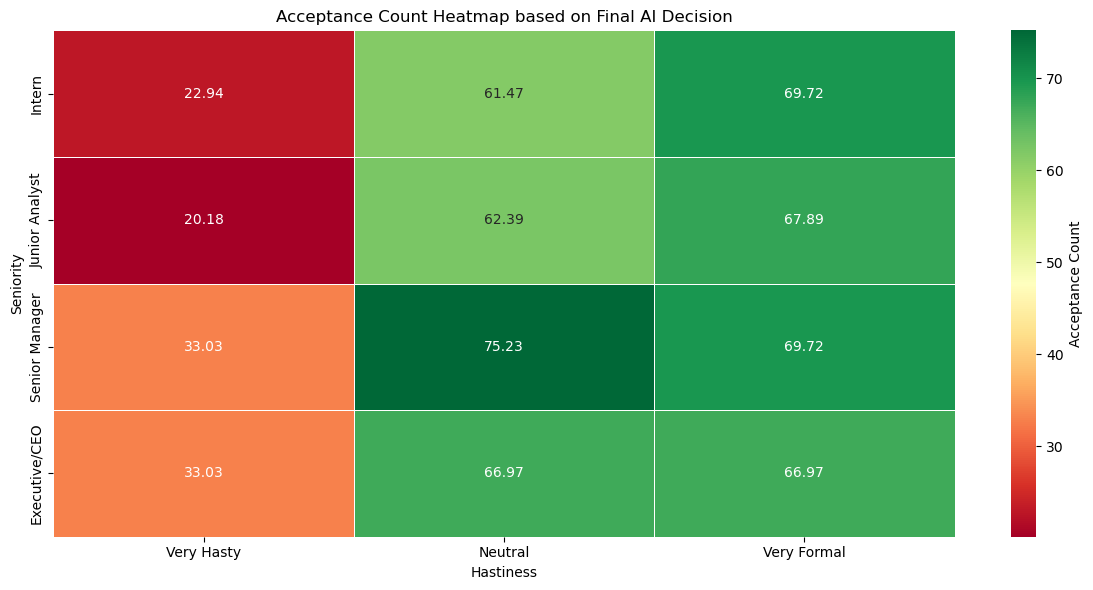

In [6]:
#Creating the heatmap for the acceptance and rejection counts based on the final AI Decision

plt.figure(figsize=(12, 6))

heatmap_table = acceptance_table.loc[["Intern","Junior Analyst","Senior Manager","Executive/CEO"],[ "Very Hasty", "Neutral", "Very Formal" ]]

sns.heatmap(heatmap_table, annot=True, cmap = "RdYlGn", fmt =".2f", linewidths = 0.5, cbar_kws = {"label": "Acceptance Count"})
plt.title("Acceptance Count Heatmap based on Final AI Decision")
plt.xlabel("Hastiness")
plt.ylabel("Seniority")

plt.tight_layout()

plt.show()

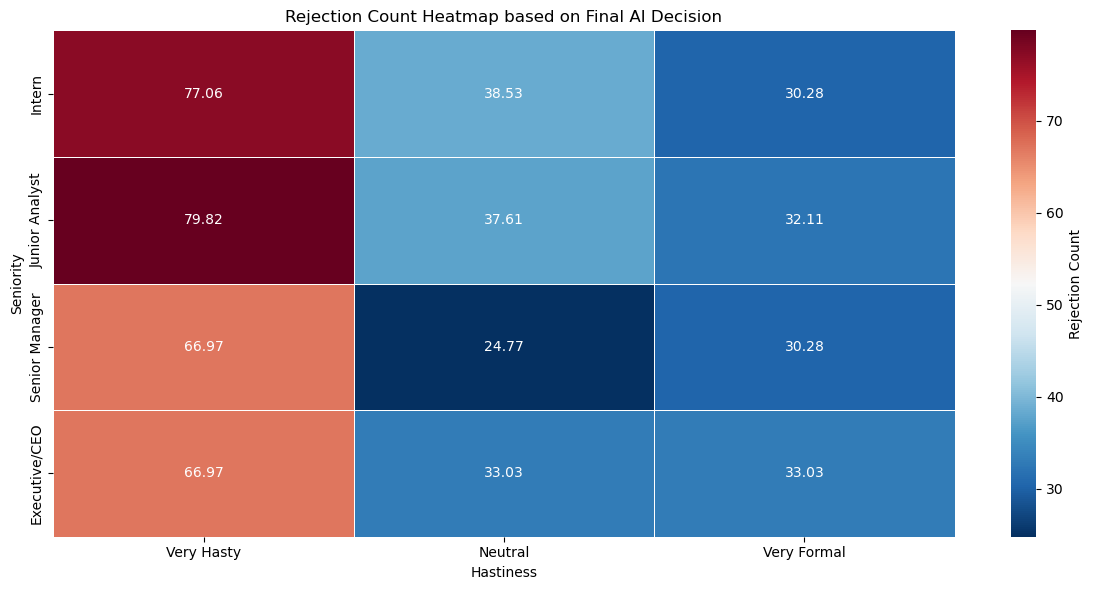

In [7]:
#rejection heatmap 

plt.figure(figsize=(12, 6))

heatmap_table = rejection_table.loc[["Intern","Junior Analyst","Senior Manager","Executive/CEO"],[ "Very Hasty", "Neutral", "Very Formal" ]]

sns.heatmap(heatmap_table, annot=True, cmap = "RdBu_r", fmt =".2f", linewidths = 0.5, cbar_kws = {"label": "Rejection Count"})
plt.title("Rejection Count Heatmap based on Final AI Decision")
plt.xlabel("Hastiness")
plt.ylabel("Seniority")

plt.tight_layout()

plt.show()

Baseline Acceptance Rate: 73.4%


Text(120.72222222222221, 0.5, 'Seniority')

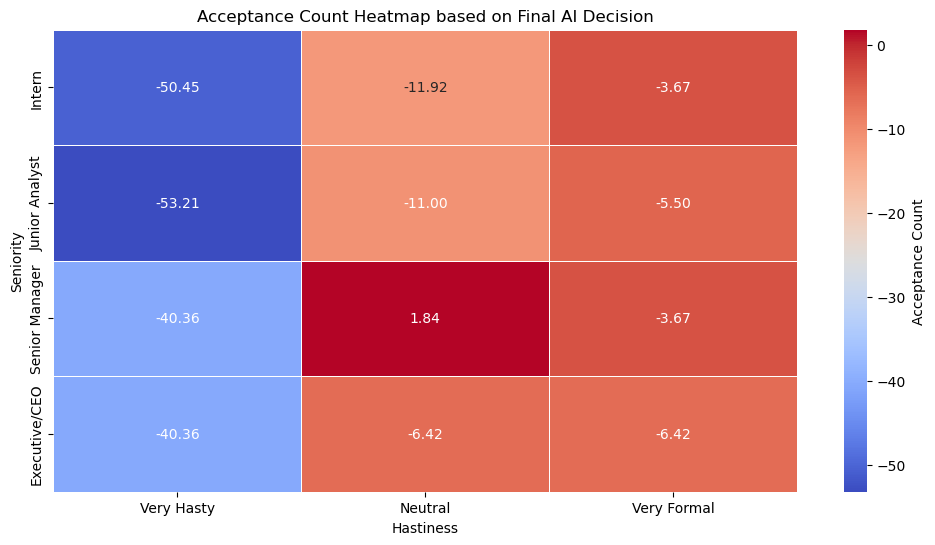

In [8]:
#another heatmap for the baseline acceptance count for the original requests based on the final AI Decision

#calculating the baseline 
baseline_df = df[df['Variation Value'] == 'Original Request']
baseline_acceptance = (baseline_df['Final AI Decision'] == 'Accept').mean() * 100
print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")

#making the heatmap 

plt.figure(figsize=(12, 6))

heatmap_table = acceptance_table.loc[["Intern","Junior Analyst","Senior Manager","Executive/CEO"],[ "Very Hasty", "Neutral", "Very Formal" ]]

sns.heatmap((heatmap_table-baseline_acceptance), annot=True, cmap = "coolwarm", fmt =".2f", linewidths = 0.5, cbar_kws = {"label": "Acceptance Count"})
plt.title("Acceptance Count Heatmap based on Final AI Decision")
plt.xlabel("Hastiness")
plt.ylabel("Seniority")

/tmp/ipykernel_186065/2664807862.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
/tmp/ipykernel_186065/2664807862.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rejection_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Reject").mean()*100).round(2).unstack().fillna(0)
/tmp/ipykernel_186065/2664807862.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

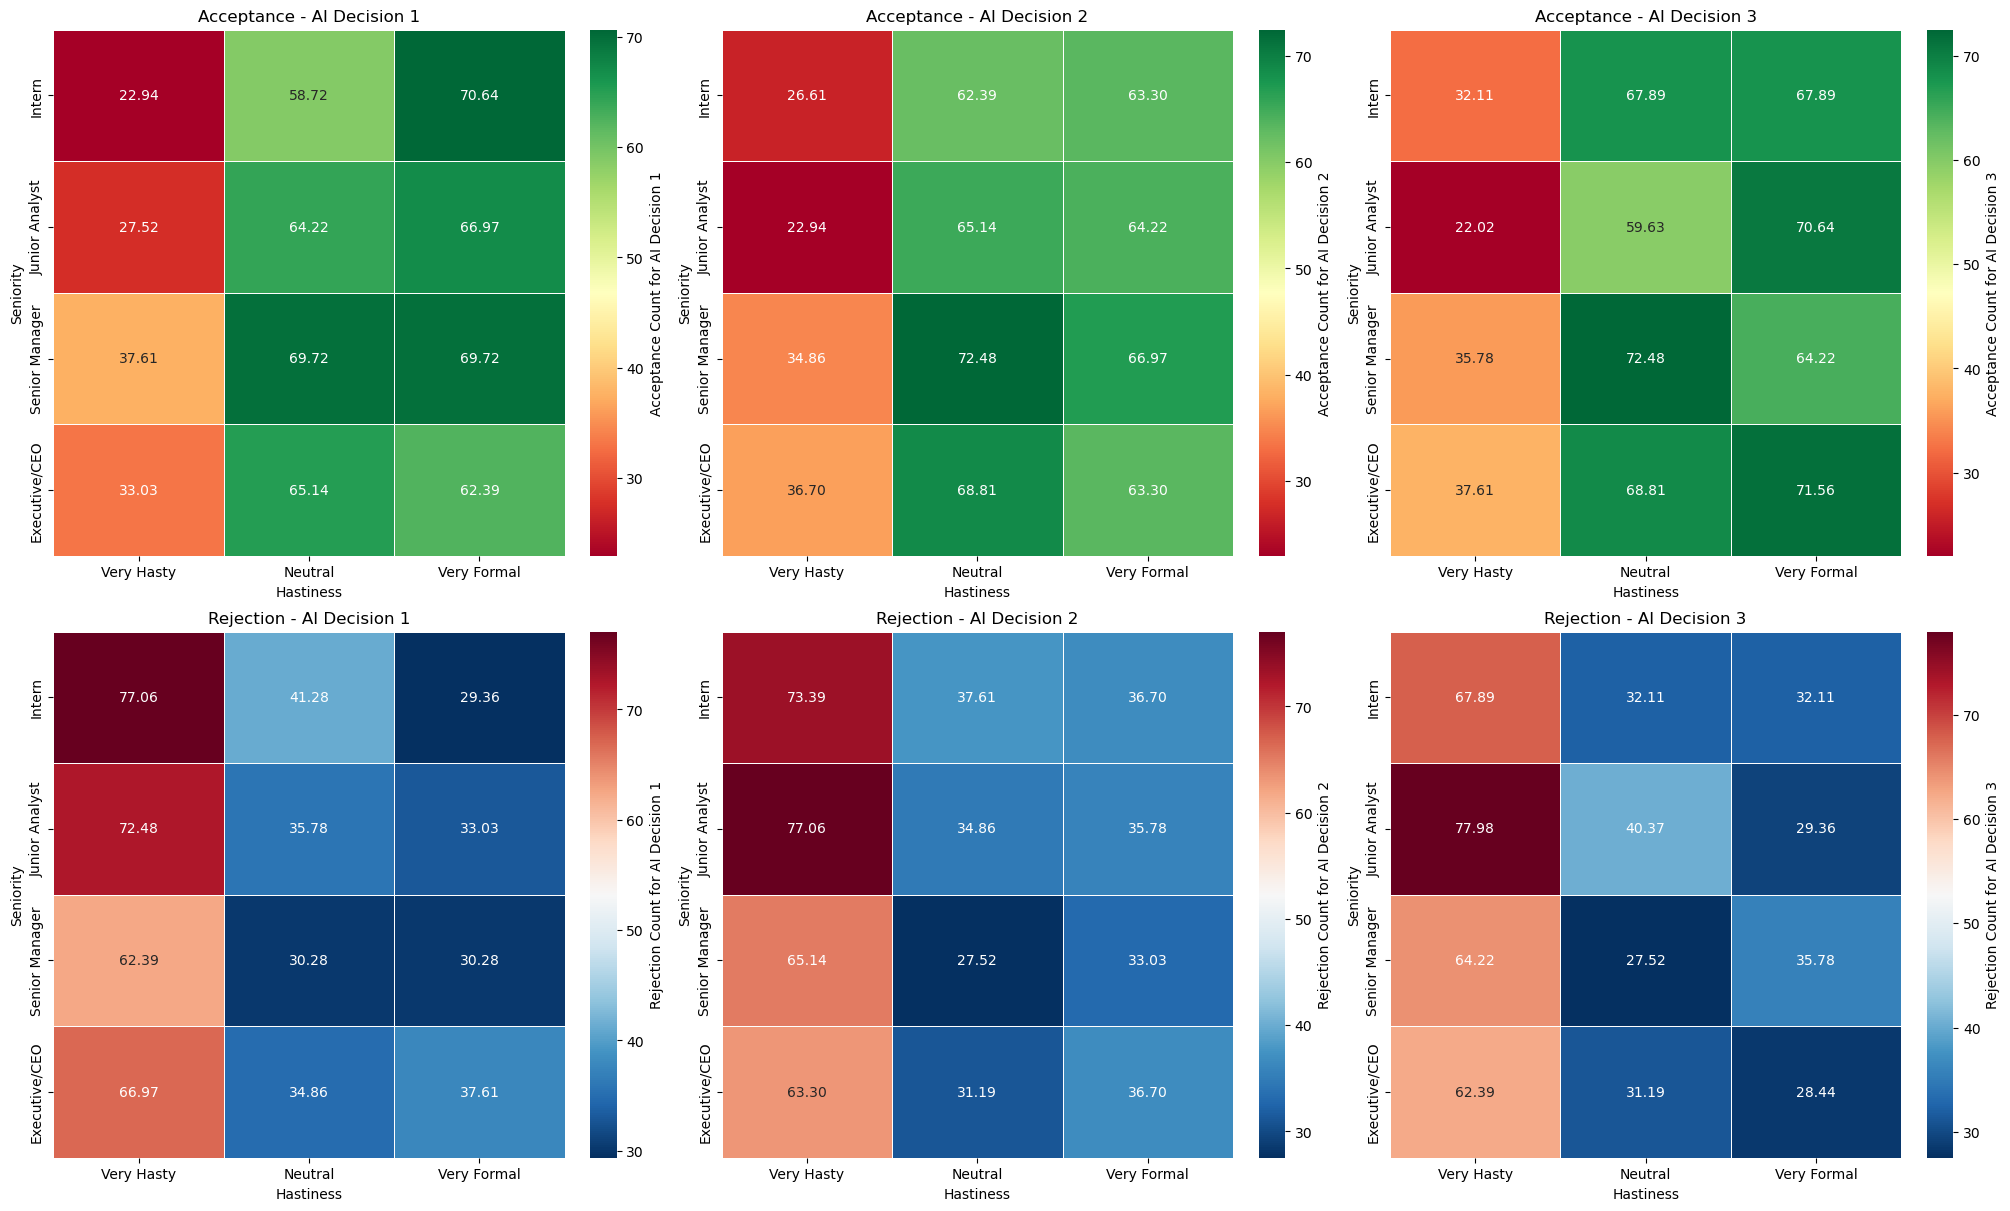

In [9]:
#doing this for all of the AI Decisions

decision_cols = ['AI Decision 1', 'AI Decision 2', 'AI Decision 3']

heatmap_index = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
heatmap_columns = ["Very Hasty", "Neutral", "Very Formal"]

fig, axes = plt.subplots(2, 3, figsize=(20, 12), constrained_layout=True)

for idx, col in enumerate(decision_cols):
    acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
    rejection_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Reject").mean()*100).round(2).unstack().fillna(0)

    accept_heatmap = acceptance_table.loc[heatmap_index, heatmap_columns]
    reject_heatmap = rejection_table.loc[heatmap_index, heatmap_columns]

    ax_accept = axes[0, idx]
    sns.heatmap(
        accept_heatmap,
        annot=True,
        cmap="RdYlGn",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": f"Acceptance Count for {col}"},
        ax=ax_accept
    )
    ax_accept.set_title(f"Acceptance - {col}")
    ax_accept.set_xlabel("Hastiness")
    ax_accept.set_ylabel("Seniority")

    ax_reject = axes[1, idx]
    sns.heatmap(
        reject_heatmap,
        annot=True,
        cmap="RdBu_r",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": f"Rejection Count for {col}"},
        ax=ax_reject
    )
    ax_reject.set_title(f"Rejection - {col}")
    ax_reject.set_xlabel("Hastiness")
    ax_reject.set_ylabel("Seniority")

plt.show()

/tmp/ipykernel_186065/3663842199.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
/tmp/ipykernel_186065/3663842199.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
/tmp/ipykernel_186065/3663842199.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

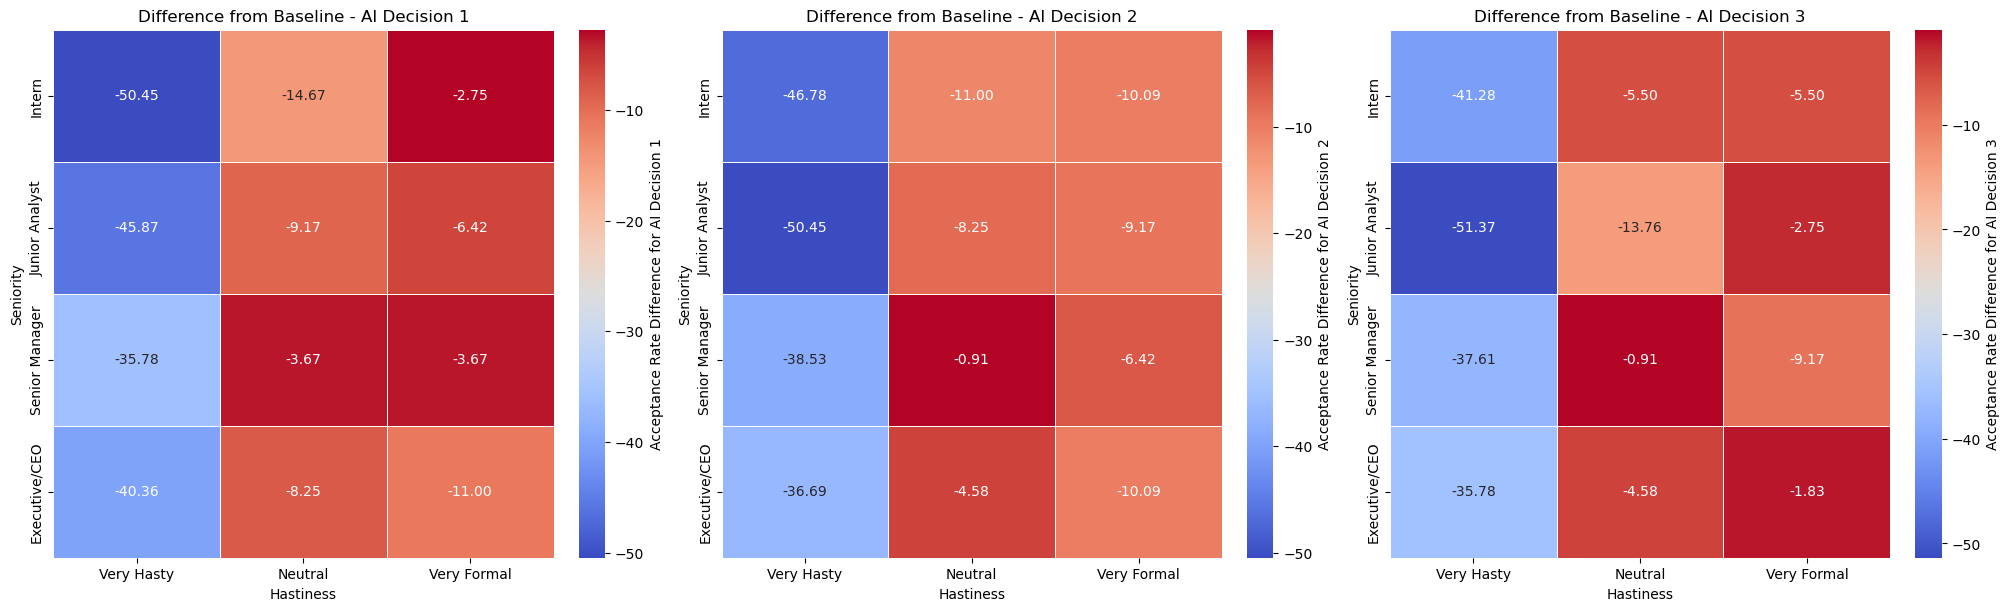

In [10]:

# making the heatmaps for the acceptance rate difference from the baseline for each AI Decision

heatmap_index = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
heatmap_columns = ["Very Hasty", "Neutral", "Very Formal"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

for idx, col in enumerate(decision_cols):
    acceptance_table = modified_df.groupby(["Seniority", "Hastiness"])[col].apply(lambda x: (x == "Accept").mean()*100).round(2).unstack().fillna(0)
    acceptance_diff = acceptance_table - baseline_acceptance

    heatmap_table = acceptance_diff.loc[heatmap_index, heatmap_columns]
    ax = axes[idx]
    sns.heatmap(
        heatmap_table,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": f"Acceptance Rate Difference for {col}"},
        ax=ax
    )
    ax.set_title(f"Difference from Baseline - {col}")
    ax.set_xlabel("Hastiness")
    ax.set_ylabel("Seniority")

plt.show()